# Partie 1: Listings Airbnb Mars 2025

## 1.Importations des bibliothéques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Importations des données et premières informations

In [2]:
df=pd.read_csv("DATA_mars_2025/listings_mars_2025.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3109,zen and calm,3631,Anne,NaN,Observatoire,48.83191,2.31870,Entire home/apt,100.0,2,4,2019-10-24,0.04,1,356,0,7511409139079
1,5396,Your perfect Paris studio on Île Saint-Louis,7903,Borzou,NaN,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,97.0,1,435,2025-02-16,2.28,1,114,45,7510402838018
2,7397,MARAIS - 2ROOMS APT - 2/4 PEOPLE,2626,Franck,NaN,Hôtel-de-Ville,48.85909,2.35315,Entire home/apt,129.0,10,373,2025-02-26,2.20,1,188,25,7510400829623
3,7964,Sunny apartment with balcony,22155,Anaïs,NaN,Opéra,48.87417,2.34245,Entire home/apt,NaN,7,5,2015-09-14,0.03,1,0,0,7510903576564
4,9359,"Cozy, Central Paris: WALK or VELIB EVERYWHERE !",28422,Bernadette,NaN,Louvre,48.86006,2.34863,Entire home/apt,75.0,180,0,NaN,NaN,1,358,0,"Available with a mobility lease only (""bail mo..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86064 entries, 0 to 86063
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              86064 non-null  int64  
 1   name                            86064 non-null  object 
 2   host_id                         86064 non-null  int64  
 3   host_name                       86023 non-null  object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   86064 non-null  object 
 6   latitude                        86064 non-null  float64
 7   longitude                       86064 non-null  float64
 8   room_type                       86064 non-null  object 
 9   price                           55655 non-null  float64
 10  minimum_nights                  86064 non-null  int64  
 11  number_of_reviews               86064 non-null  int64  
 12  last_review                     

#### Toutes les colonnes ne sont pas utiles pour notre étude, nous allons les supprimer. Puis nous traiterons les valeurs manquantes . Avant cela nous allons filtrer les données pour notre étude.

In [5]:
cols_to_keep = [
    "id", "neighbourhood", "latitude", "longitude", 
    "room_type", "price", "availability_365", 
    "number_of_reviews", "reviews_per_month", "minimum_nights"]

In [6]:
df = df[cols_to_keep]

In [7]:
df.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
0,3109,Observatoire,48.83191,2.31870,Entire home/apt,100.0,356,4,0.04,2
1,5396,Hôtel-de-Ville,48.85247,2.35835,Entire home/apt,97.0,114,435,2.28,1
2,7397,Hôtel-de-Ville,48.85909,2.35315,Entire home/apt,129.0,188,373,2.20,10
3,7964,Opéra,48.87417,2.34245,Entire home/apt,NaN,0,5,0.03,7
4,9359,Louvre,48.86006,2.34863,Entire home/apt,75.0,358,0,NaN,180


## 3. Filtrages nécessaires à notre étude

In [8]:
df = df[
    (df['latitude'] >= 48.81) & (df['latitude'] <= 48.90) &
    (df['longitude'] >= 2.25) & (df['longitude'] <= 2.42)
] # Notre choix d'étude est Paris intra-muros dont on peut trouver les latitudes et longitudes correspondantes

In [9]:
df = df[df['availability_365'] > 0] # on ne garde que les logements actifs

In [10]:
df = df[
    (df['room_type'] == "Entire home/apt") &
    (df['minimum_nights'] <= 30)
]  # les logements entiers sont les plus representatifs et les plus recherchés par les touristes et ceux-ci n'effectuent pas de séjours longue durée

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46367 entries, 0 to 86063
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 46367 non-null  int64  
 1   neighbourhood      46367 non-null  object 
 2   latitude           46367 non-null  float64
 3   longitude          46367 non-null  float64
 4   room_type          46367 non-null  object 
 5   price              43937 non-null  float64
 6   availability_365   46367 non-null  int64  
 7   number_of_reviews  46367 non-null  int64  
 8   reviews_per_month  35746 non-null  float64
 9   minimum_nights     46367 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.9+ MB


In [12]:
df.sample(10)

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
2213,2404876,Popincourt,48.863560,2.371900,Entire home/apt,295.0,115,123,0.92,3
41965,778680846221124171,Gobelins,48.835972,2.349992,Entire home/apt,200.0,351,2,2.00,1
74795,1178913552237319247,Palais-Bourbon,48.852934,2.309507,Entire home/apt,150.0,209,3,0.41,2
17954,24441009,Vaugirard,48.841770,2.281620,Entire home/apt,103.0,278,107,1.45,2
76506,1194897509211917586,Élysée,48.866970,2.303380,Entire home/apt,304.0,365,0,NaN,2
51242,948340975562391529,Luxembourg,48.853390,2.333860,Entire home/apt,171.0,273,14,0.77,2
73925,1171645741189668584,Reuilly,48.846128,2.376959,Entire home/apt,115.0,291,5,0.57,1
24528,36621551,Popincourt,48.862000,2.384000,Entire home/apt,310.0,363,0,NaN,3
51159,946315656314332395,Passy,48.856980,2.279500,Entire home/apt,180.0,252,3,0.95,3
55670,1012771756753971923,Louvre,48.865250,2.334360,Entire home/apt,NaN,5,12,0.73,3


In [13]:
df_sans_doublons=df.drop_duplicates()

In [14]:
df_sans_doublons.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46367 entries, 0 to 86063
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 46367 non-null  int64  
 1   neighbourhood      46367 non-null  object 
 2   latitude           46367 non-null  float64
 3   longitude          46367 non-null  float64
 4   room_type          46367 non-null  object 
 5   price              43937 non-null  float64
 6   availability_365   46367 non-null  int64  
 7   number_of_reviews  46367 non-null  int64  
 8   reviews_per_month  35746 non-null  float64
 9   minimum_nights     46367 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.9+ MB


####  Il n'y avait pas de doublons dans le dataset

## 4. Gestions des valeurs manquantes

#### La colonne 'Price' contient beaucoup de valeurs manquantes ( 2430) mais étant donné la taille du Dataset la perte de ces données est négligeable(environ 5%) , nous allons donc supprimer ces lignes ,c'est plus simple,plus propre pour une colonne qui a son importance.

In [15]:
df = df.dropna(subset=['price'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43937 entries, 0 to 86063
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43937 non-null  int64  
 1   neighbourhood      43937 non-null  object 
 2   latitude           43937 non-null  float64
 3   longitude          43937 non-null  float64
 4   room_type          43937 non-null  object 
 5   price              43937 non-null  float64
 6   availability_365   43937 non-null  int64  
 7   number_of_reviews  43937 non-null  int64  
 8   reviews_per_month  33846 non-null  float64
 9   minimum_nights     43937 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.7+ MB


#### Pour la colonne 'reviews_per_months' nous allons laisser la mention Nan qui peut prendre tout son sens surtout sil ny a jamais eu d'avis.Ou nous reviendrons plus tard sur cette décision.

In [17]:
nan_reviews_per_month = df[df['reviews_per_month'].isna()]
print(nan_reviews_per_month['number_of_reviews'].value_counts())

number_of_reviews
0    10091
Name: count, dtype: int64


#### Donc en effet ces valeurs manquantes correspondent au fait qu'il n'y a aucun avis . On va donc les laisser et ajouter plus tard si besoin une colonne stipulant l'absence d'avis.

## 5. Statistiques descriptives et gestion des potentiels outliers

In [18]:
df.describe()

,id,latitude,longitude,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
count,4.393700e+04,43937.000000,43937.000000,43937.000000,43937.000000,43937.000000,33846.000000,43937.000000
mean,7.669922e+17,48.863964,2.341994,261.440585,182.453399,28.852766,1.283742,5.762911
std,4.890153e+17,0.017422,0.033750,625.487133,119.874308,58.536670,1.369717,8.716327
min,3.109000e+03,48.815890,2.250700,8.000000,1.000000,0.000000,0.000000,1.000000
25%,5.280792e+07,48.851650,2.320670,102.000000,68.000000,1.000000,0.360000,2.000000
50%,9.687126e+17,48.864884,2.346266,151.000000,186.000000,8.000000,0.850000,3.000000
75%,1.141755e+18,48.877641,2.365069,251.000000,277.000000,31.000000,1.750000,4.000000
max,1.367953e+18,48.899640,2.416170,30400.000000,365.000000,957.000000,62.880000,30.000000


#### Dans la colonne prix par exemple la lecture du troisième quartile nous indique clairement que le maximum est une valeur aberrante.Nous allons détecter ces valeurs extrêmes dans les colonnes 'price' ,'minimum_nights'.

In [19]:
colonnes_à_traiter = ['price',  'minimum_nights']

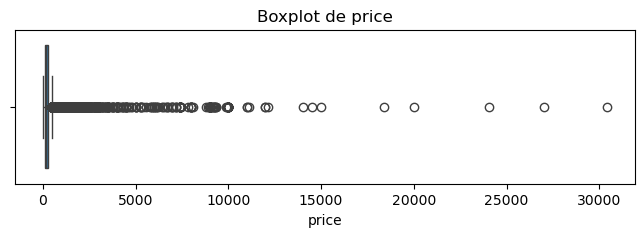

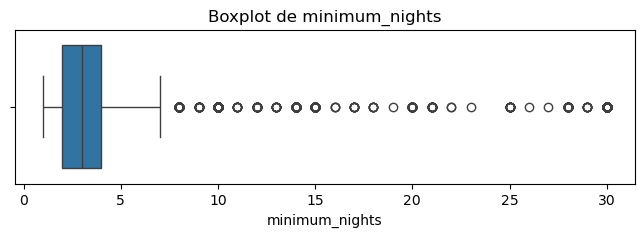

In [20]:
for col in colonnes_à_traiter:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

#### Effectivement les boxplot nous indiquent un très grand nombre de valeurs extrêmes. Il pourrait s'agir d'erreurs de saisies,de quelques logements très luxueux , très demandés ou atypiques.

In [21]:
outlier_mask = pd.DataFrame(False, index=df.index, columns=df.columns) # Un dataframe où 'False' sera remplacé par 'true' si un outlier est détecté
for col in colonnes_à_traiter :  # on  vérifie toutes les colonnes numériques sauf les colonnes binaires
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR     # calcul des quartiles et des bornes
    outlier_mask[col] = (df[col] < borne_inf) | (df[col] > borne_sup)  # le masque passera à true pour les cellules dont la valeur qui ne sont pas dans la borne
outliers = df[outlier_mask.any(axis=1)]
print("Valeurs aberrantes détectées :")
print(outliers)

Valeurs aberrantes détectées :
                        id      neighbourhood   latitude  longitude  \
2                     7397     Hôtel-de-Ville  48.859090   2.353150   
7                    11487         Popincourt  48.864410   2.371390   
25                  164306           Entrepôt  48.872770   2.373270   
33                  180950             Temple  48.867740   2.359470   
41                  194778           Panthéon  48.846090   2.351480   
...                    ...                ...        ...        ...   
86028  1366672370128974962           Gobelins  48.827665   2.350864   
86036  1366740381212797774           Panthéon  48.838940   2.357130   
86044  1366893933737618063            Reuilly  48.846164   2.408258   
86053  1367327026141978476              Passy  48.859026   2.282779   
86062  1367641263049641442  Buttes-Montmartre  48.884726   2.339431   

             room_type  price  availability_365  number_of_reviews  \
2      Entire home/apt  129.0               18

#### Supprimer 9088 lignes où apparaissent au moins un outlier est beucoup (un peu plus de 20% des données) mais pour mon étude et pour les visualisations je veux des données fiables 

In [22]:
df_clean = df[~outlier_mask.any(axis=1)]

In [23]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34849 entries, 0 to 86063
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 34849 non-null  int64  
 1   neighbourhood      34849 non-null  object 
 2   latitude           34849 non-null  float64
 3   longitude          34849 non-null  float64
 4   room_type          34849 non-null  object 
 5   price              34849 non-null  float64
 6   availability_365   34849 non-null  int64  
 7   number_of_reviews  34849 non-null  int64  
 8   reviews_per_month  28677 non-null  float64
 9   minimum_nights     34849 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 2.9+ MB


In [24]:
df_clean.describe()

,id,latitude,longitude,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights
count,3.484900e+04,34849.000000,34849.000000,34849.000000,34849.000000,34849.000000,28677.000000,34849.000000
mean,7.599900e+17,48.864406,2.344383,177.065081,174.032139,33.193033,1.402585,2.580705
std,4.903774e+17,0.017701,0.033193,94.470849,120.373206,62.847186,1.416294,1.438549
min,3.109000e+03,48.815890,2.251310,9.000000,1.000000,0.000000,0.000000,1.000000
25%,5.229257e+07,48.851810,2.324128,105.000000,60.000000,2.000000,0.440000,1.000000
50%,9.579470e+17,48.865511,2.348025,150.000000,175.000000,12.000000,0.980000,2.000000
75%,1.141117e+18,48.878580,2.367801,225.000000,271.000000,36.000000,1.900000,3.000000
max,1.367953e+18,48.899640,2.416170,474.000000,365.000000,957.000000,62.880000,7.000000


#### Nous avons maintenant une base fiable et solide 

# Partie 2: Ajout de la distance à la seine avec Geopandas

## 1. Importer le fichier 'neighbourhoods.geoson'

In [25]:
!pip install geopandas

In [26]:
import geopandas as gpd

In [27]:
gdf_neigh=gpd.read_file("DATA_mars_2025/neighbourhoods.geojson") #Importation du geodataframe

In [28]:
gdf_neigh.head()

,neighbourhood,neighbourhood_group,geometry
0,Batignolles-Monceau,None,"MULTIPOLYGON (((2.29517 48.87396, 2.29504 48.8..."
1,Palais-Bourbon,None,"MULTIPOLYGON (((2.3209 48.86306, 2.32094 48.86..."
2,Buttes-Chaumont,None,"MULTIPOLYGON (((2.38943 48.90122, 2.39014 48.9..."
3,Opéra,None,"MULTIPOLYGON (((2.33978 48.88203, 2.33982 48.8..."
4,Entrepôt,None,"MULTIPOLYGON (((2.36469 48.88437, 2.36486 48.8..."


In [29]:
gdf_neigh.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   neighbourhood        20 non-null     object  
 1   neighbourhood_group  0 non-null      object  
 2   geometry             20 non-null     geometry
dtypes: geometry(1), object(2)
memory usage: 612.0+ bytes


<Axes: >

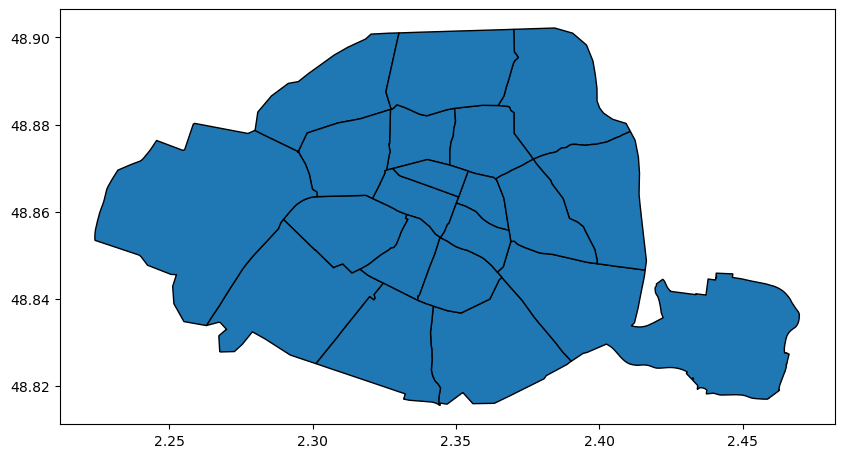

In [30]:
gdf_neigh.plot(figsize=(10, 10), edgecolor='black')

## 2. Affichage des logements sur la carte

#### Nous allons pour cela transformer notre dataframe listings en GeoDataframe

In [31]:
gdf_listings = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean.longitude, df_clean.latitude),
    crs="EPSG:4326" ) # système GPS

<Axes: >

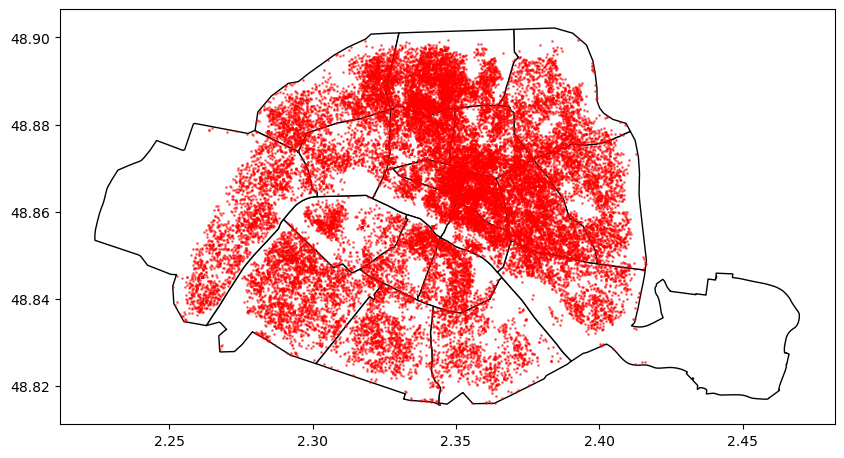

In [32]:
ax = gdf_neigh.plot(figsize=(10, 10), color="white", edgecolor="black")
gdf_listings.plot(ax=ax, markersize=1, color="red", alpha=0.5)

## 3. Récuperation de la Seine via OSM (OpenStreetMap) et ajout de la colonne distance

In [33]:
import osmnx as ox


# Définir les tags pour récupérer les cours d'eau (notamment la Seine)
tags = {"waterway": "river"}

# Télécharger les entités correspondant à ces tags à Paris
gdf = ox.features_from_place("Paris, France", tags=tags)

# Filtrer les entités dont le nom contient 'Seine'
seine = gdf[gdf['name'].str.contains("Seine", na=False)]

# Vérification
print(seine[['name', 'geometry']].head())

                                           name  \
element id                                        
way     32496111                       La Seine   
        99550443                       La Seine   
        99555151          La Seine - Bras Marie   
        99555152  La Seine - Bras de la Monnaie   
        99555154                       La Seine   

                                                           geometry  
element id                                                           
way     32496111  LINESTRING (2.40936 48.81663, 2.40762 48.8174,...  
        99550443  LINESTRING (2.23046 48.86786, 2.23093 48.86814...  
        99555151  LINESTRING (2.3614 48.84847, 2.36095 48.84931,...  
        99555152  LINESTRING (2.35386 48.85119, 2.35325 48.85125...  
        99555154  LINESTRING (2.28874 48.85721, 2.28834 48.85547...  


In [34]:
print("CRS gdf_neigh:", gdf_neigh.crs)
print("CRS seine:", seine.crs)
print("CRS gdf_listings:", gdf_listings.crs)



CRS gdf_neigh: EPSG:4326
CRS seine: epsg:4326
CRS gdf_listings: EPSG:4326


In [35]:
# Reprojection en Lambert 93 (EPSG:2154)
gdf_neigh_proj = gdf_neigh.to_crs(epsg=2154)
seine_proj = seine.to_crs(epsg=2154)
gdf_listings_proj = gdf_listings.to_crs(epsg=2154)

In [36]:
print("Bornes quartiers:", gdf_neigh_proj.total_bounds)
print("Bornes Seine:", seine_proj.total_bounds)
print("Bornes logements:", gdf_listings_proj.total_bounds)

Bornes quartiers: [ 643065.72945475 6857478.61174764  661079.59645316 6867082.55627783]
Bornes Seine: [ 642959.80567831 6857558.49823922  656629.75470821 6867009.69615124]
Bornes logements: [ 645052.06554284 6857513.67979014  657155.49487356 6866811.29596582]


C:\Users\huvelle\AppData\Local\Temp\ipykernel_9780\2014433909.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


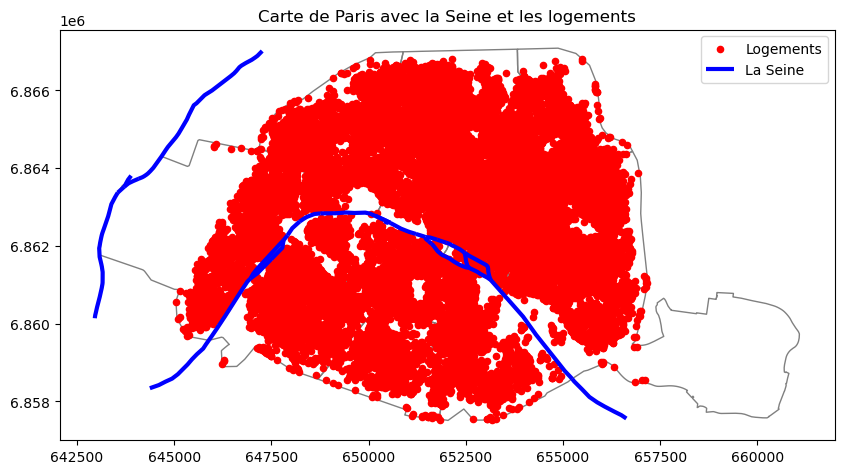

In [37]:
from shapely.ops import unary_union

seine_unie = unary_union(seine_proj.geometry)

fig, ax = plt.subplots(figsize=(10,10))
gdf_neigh_proj.plot(ax=ax, facecolor='none', edgecolor='gray', label='Quartiers')
gdf_listings_proj.plot(ax=ax, color='red', markersize=20, label='Logements')
gpd.GeoSeries(seine_unie).plot(ax=ax, color='blue', linewidth=3, label='La Seine')

plt.legend()
plt.title("Carte de Paris avec la Seine et les logements")
plt.show()

In [38]:
gdf_listings_proj['distance_seine'] = gdf_listings_proj.geometry.apply(lambda x: x.distance(seine_unie))
print(gdf_listings_proj[['distance_seine']].head())

   distance_seine
0     3106.596279
1        7.282508
5     1550.169728
6     2795.482280
8     1314.016649


In [39]:
gdf_listings_proj.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,geometry,distance_seine
0,3109,Observatoire,48.831910,2.318700,Entire home/apt,100.0,356,4,0.04,2,POINT (649987.402 6859310.674),3106.596279
1,5396,Hôtel-de-Ville,48.852470,2.358350,Entire home/apt,97.0,114,435,2.28,1,POINT (652916.524 6861572.356),7.282508
5,9952,Popincourt,48.863730,2.370930,Entire home/apt,120.0,176,52,0.36,4,POINT (653849.584 6862816.946),1550.169728
6,11265,Buttes-Montmartre,48.884940,2.339970,Entire home/apt,145.0,74,34,0.32,7,POINT (651598.033 6865193.888),2795.482280
8,11798,Gobelins,48.825241,2.367469,Entire home/apt,105.0,342,121,0.80,3,POINT (653561.403 6858539.383),1314.016649


#### Supprimons la colonne 'geometry' et renommons proprement ce Dataset

In [40]:
# 1. Supprimer la colonne 'geometry'
df_enrichi = gdf_listings_proj.drop(columns='geometry')

In [41]:
df_enrichi.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine
0,3109,Observatoire,48.831910,2.318700,Entire home/apt,100.0,356,4,0.04,2,3106.596279
1,5396,Hôtel-de-Ville,48.852470,2.358350,Entire home/apt,97.0,114,435,2.28,1,7.282508
5,9952,Popincourt,48.863730,2.370930,Entire home/apt,120.0,176,52,0.36,4,1550.169728
6,11265,Buttes-Montmartre,48.884940,2.339970,Entire home/apt,145.0,74,34,0.32,7,2795.482280
8,11798,Gobelins,48.825241,2.367469,Entire home/apt,105.0,342,121,0.80,3,1314.016649


# Partie3: Ajout du prix moyen journalier via calendar (mars 2025)

## 1. Importation du fichier calendar 

In [42]:
calendar = pd.read_csv("DATA_mars_2025/calendar_mars_2025.csv.gz", compression='gzip',low_memory=False)

In [43]:
calendar.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,3109,2025-03-11,f,$100.00,NaN,2.0,30.0
1,3109,2025-03-12,t,$100.00,NaN,2.0,30.0
2,3109,2025-03-13,t,$100.00,NaN,2.0,30.0
3,3109,2025-03-14,t,$100.00,NaN,2.0,30.0
4,3109,2025-03-15,t,$100.00,NaN,2.0,30.0


In [44]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31442697 entries, 0 to 31442696
Data columns (total 7 columns):
 #   Column          Dtype  
---  ------          -----  
 0   listing_id      int64  
 1   date            object 
 2   available       object 
 3   price           object 
 4   adjusted_price  object 
 5   minimum_nights  float64
 6   maximum_nights  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 1.6+ GB


In [45]:
calendar.sample(15)

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
10191161,44167847,2025-10-03,f,$120.00,NaN,3.0,1125.0
20669047,1039353618955894672,2025-11-25,f,$555.00,NaN,3.0,365.0
21584198,1067890216754592615,2025-05-27,f,$390.00,NaN,2.0,365.0
11967032,53929137,2025-09-22,t,$105.00,NaN,3.0,90.0
30886352,1361548087654683515,2025-07-24,t,$202.00,NaN,3.0,1125.0
10902058,49441312,2025-10-10,f,$70.00,NaN,15.0,1125.0
7166462,29753222,2025-03-18,f,$55.00,NaN,4.0,7.0
19032558,978737735847034258,2025-04-03,f,$450.00,NaN,2.0,31.0
2785122,10696686,2025-08-01,t,$280.00,NaN,365.0,1125.0
28499127,1238246520611323804,2025-06-11,t,$600.00,NaN,2.0,365.0


In [46]:
calendar.isnull().sum()

listing_id               0
date                     0
available                0
price                    0
adjusted_price    31414909
minimum_nights       32947
maximum_nights       32947
dtype: int64

## 2.Nettoyage du fichier et filtrages

In [47]:
# convertion de la date en datetime
calendar['date'] = pd.to_datetime(calendar['date'])

In [48]:
# Filtrer sur mars 2025 uniquement
calendar = calendar[
    (calendar['date'].dt.month == 3) & 
    (calendar['date'].dt.year == 2025)
] 

In [49]:
# Filtrer les logements disponibles 
calendar_dispo = calendar[calendar['available'] == 't'].copy()

In [50]:
# Nettoyons la colonne price
calendar_dispo['price'] = calendar_dispo['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
calendar_dispo['price'] = calendar_dispo['price'].replace('nan', np.nan).astype(float)
calendar_dispo = calendar_dispo[calendar_dispo['price'] > 0]

In [52]:
# Filtrons et gardons les prix inférieurs à 500€
calendar_dispo = calendar_dispo[
    (calendar_dispo['price'] <= 500)
]

In [53]:
# Supprimer colonnes inutiles
calendar_dispo = calendar_dispo.drop(columns=['adjusted_price', 'minimum_nights', 'maximum_nights', 'available'])

## 3. Calculer prix moyen journalier par logement

In [54]:
prix_moyen = calendar_dispo.groupby('listing_id')['price'].mean().reset_index()
prix_moyen.rename(columns={'price': 'prix_moyen_journalier'}, inplace=True)

## 4. Fusion avec le dataframe listings enrichi (avec distance à la Seine, quartier...)


In [55]:
df_final = df_enrichi.merge(prix_moyen, left_on='id', right_on='listing_id', how='left')

In [56]:
df_final.head()

,id,neighbourhood,latitude,longitude,room_type,price,availability_365,number_of_reviews,reviews_per_month,minimum_nights,distance_seine,listing_id,prix_moyen_journalier
0,3109,Observatoire,48.831910,2.318700,Entire home/apt,100.0,356,4,0.04,2,3106.596279,3109.0,100.0
1,5396,Hôtel-de-Ville,48.852470,2.358350,Entire home/apt,97.0,114,435,2.28,1,7.282508,5396.0,125.0
2,9952,Popincourt,48.863730,2.370930,Entire home/apt,120.0,176,52,0.36,4,1550.169728,NaN,NaN
3,11265,Buttes-Montmartre,48.884940,2.339970,Entire home/apt,145.0,74,34,0.32,7,2795.482280,NaN,NaN
4,11798,Gobelins,48.825241,2.367469,Entire home/apt,105.0,342,121,0.80,3,1314.016649,11798.0,110.0


In [57]:
# Nettoyons df_final en supprimant colonnes inutiles 
df_final.drop(columns=['listing_id', 'price', 'room_type'], inplace=True )

In [58]:
# vérification
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34849 entries, 0 to 34848
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     34849 non-null  int64  
 1   neighbourhood          34849 non-null  object 
 2   latitude               34849 non-null  float64
 3   longitude              34849 non-null  float64
 4   availability_365       34849 non-null  int64  
 5   number_of_reviews      34849 non-null  int64  
 6   reviews_per_month      28677 non-null  float64
 7   minimum_nights         34849 non-null  int64  
 8   distance_seine         34849 non-null  float64
 9   prix_moyen_journalier  25064 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 2.7+ MB


#### Le fait qu'on ai 8 343 logements sans prix moyen est normal vu les conditions :

#### On travailles uniquement sur mars 2025

#### On ne prends que les logements disponibles

#### Donc si un logement n’est pas dispo en mars, ou qu’il n’a pas de prix renseigné à ces dates → pas de prix moyen.

In [59]:
df_final = df_final[df_final['prix_moyen_journalier'].notna()]

In [60]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25064 entries, 0 to 34848
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     25064 non-null  int64  
 1   neighbourhood          25064 non-null  object 
 2   latitude               25064 non-null  float64
 3   longitude              25064 non-null  float64
 4   availability_365       25064 non-null  int64  
 5   number_of_reviews      25064 non-null  int64  
 6   reviews_per_month      20197 non-null  float64
 7   minimum_nights         25064 non-null  int64  
 8   distance_seine         25064 non-null  float64
 9   prix_moyen_journalier  25064 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 2.1+ MB


#### Enfin, ajoutons une colonne 'période' pour ajouter une variable temporelle à notre projet

In [61]:
df_final['periode'] = 'mars_2025'

In [62]:
df_final_mars2025=df_final.copy()

In [63]:
df_final_mars2025.to_csv("../OUTPUT/listings_mars2025_clean.csv", index=False)